In [6]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.stats import pearsonr, spearmanr
import spacy

In [7]:
def obtener_ruta_archivos(nombre_carpeta="archivos"):
    # Busca la carpeta desde el directorio actual hacia arriba
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        ruta = candidato / nombre_carpeta
        if ruta.is_dir():
            return ruta
    raise FileNotFoundError(f"No logré encontrar la carpeta '{nombre_carpeta}'.")

# 1. Configuración de rutas
try:
    DIR_ARCHIVOS = obtener_ruta_archivos("archivos")
except FileNotFoundError as e:
    DIR_ARCHIVOS = Path("./archivos")
    if not DIR_ARCHIVOS.exists():
        raise e

extensiones_texto = {".txt"}
paths = sorted([
    p for p in DIR_ARCHIVOS.iterdir() 
    if p.suffix.lower() in extensiones_texto and p.is_file()
])

def limpiar_markdown(texto):
    texto = re.sub(r"```.*?```", " ", texto, flags=re.S)
    texto = re.sub(r"\$\$.*?\$\$", " ", texto, flags=re.S)
    texto = re.sub(r"`[^`]*`", " ", texto)
    texto = re.sub(r"\[[^\]]*\]\([^\)]*\)", " ", texto)
    texto = re.sub(r"[^\w ]", " ", texto, flags=re.UNICODE)
    texto = re.sub(r"\s+", " ", texto)
    return texto.lower().strip()

# 3. Procesamiento de documentos
documentos = [limpiar_markdown(path.read_text(encoding="utf-8")) for path in paths]
etiquetas = [path.name for path in paths]

# 4. Resultados
print(f"Documentos encontrados en '{DIR_ARCHIVOS.name}': {len(documentos)}")
for etiqueta in etiquetas:
    print(f" - {etiqueta}")

Documentos encontrados en 'archivos': 48
 - 1.txt
 - 10.txt
 - 11.txt
 - 12.txt
 - 13.txt
 - 14.txt
 - 15.txt
 - 16.txt
 - 17.txt
 - 18.txt
 - 19.txt
 - 2.txt
 - 20.txt
 - 21.txt
 - 22.txt
 - 23.txt
 - 24.txt
 - 25.txt
 - 26.txt
 - 27.txt
 - 28.txt
 - 29.txt
 - 3.txt
 - 30.txt
 - 31.txt
 - 32.txt
 - 33.txt
 - 34.txt
 - 35.txt
 - 36.txt
 - 37.txt
 - 38.txt
 - 39.txt
 - 4.txt
 - 40.txt
 - 41.txt
 - 42.txt
 - 43.txt
 - 44.txt
 - 45.txt
 - 46.txt
 - 47.txt
 - 48.txt
 - 5.txt
 - 6.txt
 - 7.txt
 - 8.txt
 - 9.txt


# Conteo de terminos sin limpieza

In [8]:
for style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "default"]:
    if style in plt.style.available or style == "default":
        plt.style.use(style)
        break

vectorizer_raw = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=1,
)

X_raw = vectorizer_raw.fit_transform(documentos)
vocabulario_raw = vectorizer_raw.get_feature_names_out()
A_raw = X_raw.toarray().T

print("Forma de X_raw (documentos x terminos):", X_raw.shape)
print("Forma de A_raw (terminos x documentos):", A_raw.shape)
print("Primeros terminos del vocabulario:", vocabulario_raw[:30])


Forma de X_raw (documentos x terminos): (48, 5746)
Forma de A_raw (terminos x documentos): (5746, 48)
Primeros terminos del vocabulario: ['aaru' 'abandon' 'abandoned' 'abandonment' 'abdicated' 'aberaku'
 'aberewaa' 'abhorrent' 'abilities' 'ability' 'able' 'abnormal' 'abode'
 'abolished' 'about' 'above' 'aboveground' 'abrax' 'absence' 'absolutely'
 'absorb' 'absorbed' 'absorbing' 'abstained' 'abstract' 'abundance'
 'abyss' 'abyssal' 'academia' 'academic']


### Diagnostico Inicial

,estadistica,corpus_sin_limpieza
0,numero_documentos,48
1,numero_terminos,5746
2,forma_X_documentos_x_terminos,48 x 5746
3,forma_A_terminos_x_documentos,5746 x 48
4,entradas_no_cero,18211
5,densidad,0.066
6,sparsity,0.934


,estadistica,corpus_sin_limpieza
0,min,192.00
1,mediana,634.00
2,media,772.23
3,max,2280.00


,estadistica,corpus_sin_limpieza
0,min,122.0
1,mediana,333.0
2,media,379.4
3,max,889.0


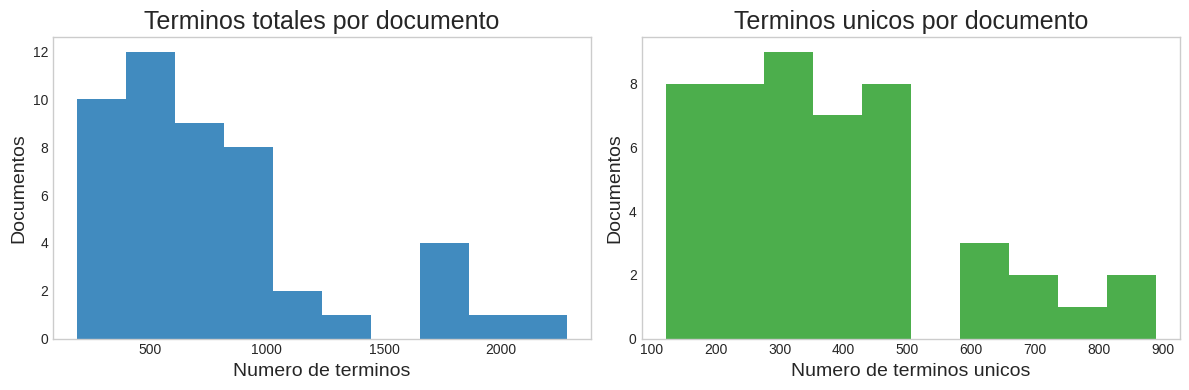

In [9]:
def tabla_resumen_distribucion(nombre, valores):
    return pd.DataFrame(
        [
            ["min", int(valores.min())],
            ["mediana", int(np.median(valores))],
            ["media", round(float(valores.mean()), 2)],
            ["max", int(valores.max())],
        ],
        columns=["estadistica", nombre],
    )


def resumen_vectorizacion(nombre, X, A, vocabulario):
    conteos_por_doc = np.asarray(X.sum(axis=1)).ravel()
    terminos_unicos_por_doc = np.asarray((X > 0).sum(axis=1)).ravel()
    total_celdas = X.shape[0] * X.shape[1]
    densidad = X.nnz / total_celdas

    tabla_corpus = pd.DataFrame(
        [
            ["numero_documentos", X.shape[0]],
            ["numero_terminos", X.shape[1]],
            ["forma_X_documentos_x_terminos", f"{X.shape[0]} x {X.shape[1]}"],
            ["forma_A_terminos_x_documentos", f"{A.shape[0]} x {A.shape[1]}"],
            ["entradas_no_cero", X.nnz],
            ["densidad", round(float(densidad), 4)],
            ["sparsity", round(float(1 - densidad), 4)],
        ],
        columns=["estadistica", nombre],
    )
    tabla_terminos_por_doc = tabla_resumen_distribucion(nombre, conteos_por_doc)
    tabla_terminos_unicos_por_doc = tabla_resumen_distribucion(nombre, terminos_unicos_por_doc)

    return (
        tabla_corpus,
        tabla_terminos_por_doc,
        tabla_terminos_unicos_por_doc,
        conteos_por_doc,
        terminos_unicos_por_doc,
    )

(
    tabla_corpus_raw,
    tabla_terminos_por_doc_raw,
    tabla_terminos_unicos_por_doc_raw,
    conteos_doc_raw,
    terminos_unicos_doc_raw,
) = resumen_vectorizacion(
    "corpus_sin_limpieza",
    X_raw,
    A_raw,
    vocabulario_raw,
)

display(tabla_corpus_raw)
display(tabla_terminos_por_doc_raw)
display(tabla_terminos_unicos_por_doc_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conteos_doc_raw, bins=10, color="tab:blue", alpha=0.85)
axes[0].set_title("Terminos totales por documento", fontsize=18)
axes[0].set_xlabel("Numero de terminos", fontsize=14)
axes[0].set_ylabel("Documentos", fontsize=14)
axes[0].grid(False)

axes[1].hist(terminos_unicos_doc_raw, bins=10, color="tab:green", alpha=0.85)
axes[1].set_title("Terminos unicos por documento", fontsize=18)
axes[1].set_xlabel("Numero de terminos unicos", fontsize=14)
axes[1].set_ylabel("Documentos", fontsize=14)
axes[1].grid(False)

plt.tight_layout()
plt.show()


#### Que palabras dominan antes de limpiar.

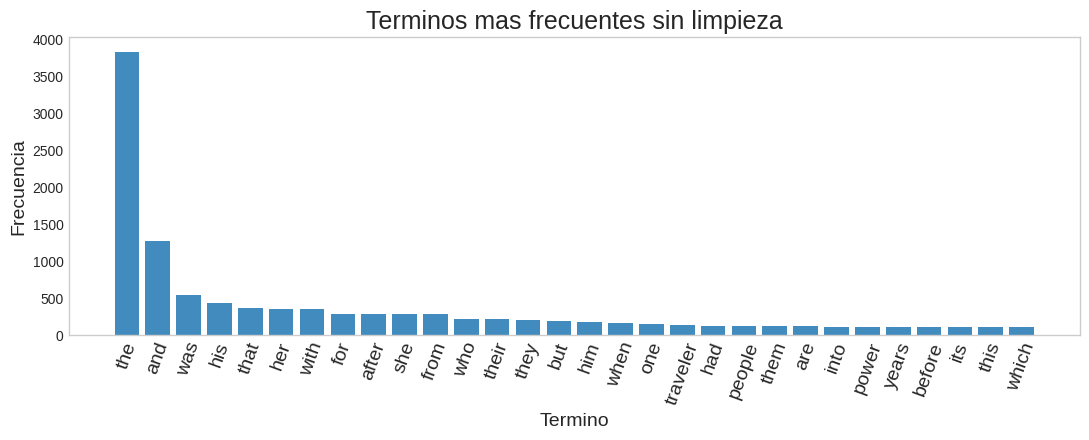

Top 30 terminos mas frecuentes sin limpieza:


array(['the', 'and', 'was', 'his', 'that', 'her', 'with', 'for', 'after',
       'she', 'from', 'who', 'their', 'they', 'but', 'him', 'when', 'one',
       'traveler', 'had', 'people', 'them', 'are', 'into', 'power',
       'years', 'before', 'its', 'this', 'which'], dtype=object)

In [10]:
frecuencias_raw = np.asarray(X_raw.sum(axis=0)).ravel()
indices_frecuentes_raw = np.argsort(frecuencias_raw)[::-1][:30]
terminos_frecuentes_raw = vocabulario_raw[indices_frecuentes_raw]
conteos_frecuentes_raw = frecuencias_raw[indices_frecuentes_raw]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(terminos_frecuentes_raw, conteos_frecuentes_raw, color="tab:blue", alpha=0.85)
ax.set_title("Terminos mas frecuentes sin limpieza", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.show()

# Print top 30 terms and their counts
print("Top 30 terminos mas frecuentes sin limpieza:")
terminos_frecuentes_raw


Interpretacion: :v

#### SVD de la matriz de conteos sin limpieza

Primeros valores singulares sin limpieza:
[745.325 105.16   96.63   82.928  71.953  67.874  60.888  58.008  53.744
  52.11 ]


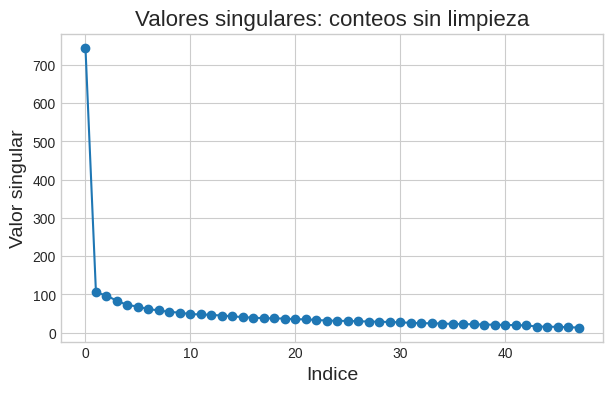

In [11]:
U_raw, s_raw, VT_raw = np.linalg.svd(A_raw, full_matrices=False)

print("Primeros valores singulares sin limpieza:")
print(np.round(s_raw[:10], 3))

plt.figure(figsize=(7, 4))
plt.plot(s_raw, marker="o")
plt.title("Valores singulares: conteos sin limpieza", fontsize=16)
plt.xlabel("Indice", fontsize=14)
plt.ylabel("Valor singular", fontsize=14)
plt.show()

Interpretacion: Terrible tragedia

#### Funciones auxiliares para interpretacion de componentes

In [12]:
def coordenadas_documentos(s, VT, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return np.diag(s[indices]) @ VT[indices, :]


def coordenadas_terminos(U, s, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return U[:, indices] @ np.diag(s[indices])


def etiqueta_corta_documento(etiqueta):
    return Path(etiqueta).stem


def grupo_documento(etiqueta):
    partes = etiqueta.split("/")
    if len(partes) >= 3 and partes[0] == "semana" and partes[1].isdigit():
        numero = int(partes[1])
        if 1 <= numero <= 8:
            return f"S{numero:02d}"
    return "otros"


def colores_documentos(etiquetas_docs):
    cmap_semanas = plt.get_cmap("tab10")
    colores_semanas = {f"S{i:02d}": cmap_semanas(0.22 + 0.68 * (i - 1) / 7) for i in range(1, 9)}
    mapa_colores = {**colores_semanas, "otros": "tab:gray"}
    grupos = [grupo_documento(etiqueta) for etiqueta in etiquetas_docs]
    colores = [mapa_colores.get(grupo, "tab:gray") for grupo in grupos]
    return grupos, colores, mapa_colores

def graficar_documentos_y_terminos(
    coords_docs,
    coords_terms,
    etiquetas_docs,
    vocabulario,
    frecuencias_terminos,
    titulo,
    componentes=(1, 2),
    n_terms=40,
):
    normas_terms = np.linalg.norm(coords_terms, axis=1)
    indices_terms = np.argsort(normas_terms)[::-1][:n_terms]
    term_freq = np.asarray(frecuencias_terminos).ravel()
    term_freq_plot = np.maximum(term_freq[indices_terms], 1)

    grupos_docs, colores_docs, mapa_colores_docs = colores_documentos(etiquetas_docs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    axes[0].scatter(
        coords_docs[0, :],
        coords_docs[1, :],
        s=95,
        c=colores_docs,
        edgecolor="white",
        linewidth=0.7,
    )
    texts_docs = []
    for i, etiqueta in enumerate(etiquetas_docs):
        texts_docs.append(
            axes[0].text(
                coords_docs[0, i],
                coords_docs[1, i],
                etiqueta_corta_documento(etiqueta),
                fontsize=11,
            )
        )
    axes[0].grid(False)
    adjust_text(
        texts_docs,
        ax=axes[0],
        expand_text=(1.25, 1.45),
        expand_points=(1.25, 1.45),
        force_text=(0.5, 0.7),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[0].axhline(0, color="gray", linewidth=1.0)
    axes[0].axvline(0, color="gray", linewidth=1.0)
    axes[0].set_title("Documentos", fontsize=18)
    axes[0].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[0].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[0].tick_params(axis="both", labelsize=12)

    grupos_presentes = []
    for grupo in grupos_docs:
        if grupo not in grupos_presentes:
            grupos_presentes.append(grupo)
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=grupo,
            markerfacecolor=mapa_colores_docs.get(grupo, "tab:brown"),
            markeredgecolor="white",
            markersize=10,
        )
        for grupo in grupos_presentes
    ]
    axes[0].legend(handles=handles, fontsize=10, loc="best", frameon=True, ncol=2)

    normalizador = LogNorm(vmin=max(term_freq_plot.min(), 1), vmax=max(term_freq_plot.max(), 1))
    scatter_terms = axes[1].scatter(
        coords_terms[indices_terms, 0],
        coords_terms[indices_terms, 1],
        s=75,
        c=term_freq_plot,
        cmap="viridis",
        norm=normalizador,
        edgecolor="white",
        linewidth=0.5,
    )
    texts_terms = []
    axes[1].grid(False)
    for i in indices_terms:
        texts_terms.append(axes[1].text(coords_terms[i, 0], coords_terms[i, 1], vocabulario[i], fontsize=10))
    adjust_text(
        texts_terms,
        ax=axes[1],
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
        force_text=(0.45, 0.65),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[1].axhline(0, color="gray", linewidth=1.0)
    axes[1].axvline(0, color="gray", linewidth=1.0)
    axes[1].set_title("Terminos", fontsize=18)
    axes[1].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[1].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[1].tick_params(axis="both", labelsize=12)
    cax = axes[1].inset_axes([1.04, 0, 0.04, 1])
    cax.grid(False)
    cbar = fig.colorbar(scatter_terms, cax=cax)
    cbar.ax.grid(False)
    cbar.set_label("Frecuencia en el corpus", fontsize=12)
    cbar.ax.tick_params(labelsize=11)

    fig.suptitle(titulo, fontsize=20)
    plt.tight_layout()
    plt.show()


def seleccionar_top_por_signo(nombres, scores, k=8, acortar=None):
    scores = np.asarray(scores)
    top_abs = np.argsort(np.abs(scores))[::-1][:k]
    ordenados = sorted(top_abs, key=lambda i: scores[i])
    etiquetas_plot = [acortar(nombres[i]) if acortar else nombres[i] for i in ordenados]
    scores_plot = scores[ordenados]
    return etiquetas_plot, scores_plot


def graficar_barras_componente(
    U,
    s,
    VT,
    vocabulario,
    etiquetas,
    componente,
    k=10,
    titulo="",
):
    idx = componente - 1
    scores_docs = s[idx] * VT[idx, :]
    scores_terms = s[idx] * U[:, idx]

    docs_labels, docs_scores = seleccionar_top_por_signo(
        etiquetas,
        scores_docs,
        k=k,
        acortar=etiqueta_corta_documento,
    )
    term_labels, term_scores = seleccionar_top_por_signo(
        vocabulario,
        scores_terms,
        k=k,
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 8.5), sharey=False)
    cmap = plt.get_cmap("coolwarm_r")

    for ax, labels, scores, subtitulo in [
        (axes[0], docs_labels, docs_scores, "Documentos"),
        (axes[1], term_labels, term_scores, "Terminos"),
    ]:
        max_abs = max(np.max(np.abs(scores)), 1e-12)
        colores = cmap((scores / max_abs + 1) / 2)
        y = np.arange(len(scores))
        ax.barh(y, scores, color=colores, edgecolor="white", linewidth=0.7)
        ax.axvline(0, color="0.25", linewidth=1)
        ax.set_yticks([])
        ax.set_title(subtitulo, fontsize=18)
        ax.set_xlabel("Score", fontsize=15)
        ax.grid(False)
        ax.invert_yaxis()
        ax.tick_params(axis="x", labelsize=13)

        desplazamiento = 0.03 * max_abs
        for yi, score, label in zip(y, scores, labels):
            if score < 0:
                x = desplazamiento
                ha = "left"
            else:
                x = -desplazamiento
                ha = "right"
            ax.text(x, yi, label, va="center", ha=ha, fontsize=12)

        limite = 1.35 * max_abs
        ax.set_xlim(-limite, limite)

    fig.suptitle(titulo or f"Componente {componente}", fontsize=20)
    plt.tight_layout()
    plt.show()

def graficar_componentes(
    U,
    s,
    VT,
    vocabulario,
    etiquetas,
    componentes=4,
    k=10,
    titulo="",
):
    for componente in range(1, componentes + 1):
        graficar_barras_componente(
            U,
            s,
            VT,
            vocabulario,
            etiquetas,
            componente=componente,
            k=k,
            titulo=f"{titulo} - Componente {componente}" if titulo else f"Componente {componente}",
        )


Planos 2D documentos sin limpieza

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


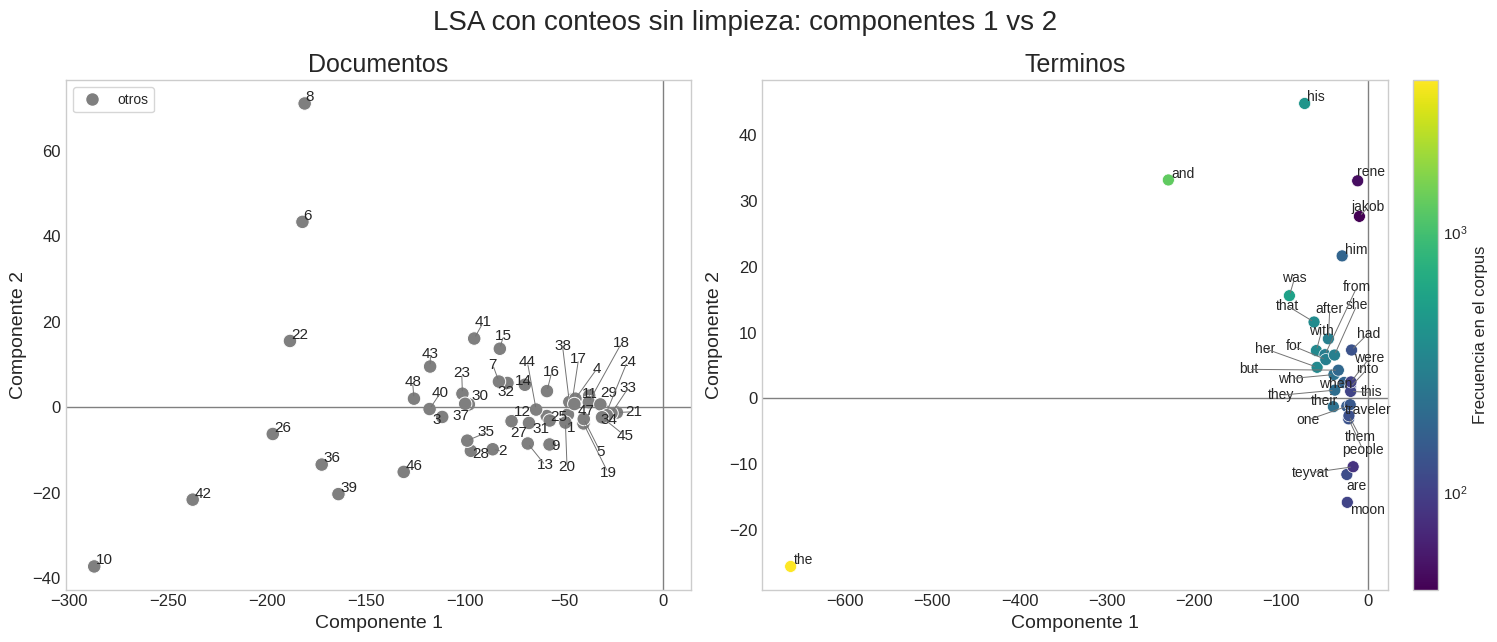

In [13]:
docs_12_raw = coordenadas_documentos(s_raw, VT_raw, componentes=(1, 2))
terms_12_raw = coordenadas_terminos(U_raw, s_raw, componentes=(1, 2))

graficar_documentos_y_terminos(
    docs_12_raw,
    terms_12_raw,
    etiquetas,
    vocabulario_raw,
    frecuencias_raw,
    "LSA con conteos sin limpieza: componentes 1 vs 2",
    componentes=(1, 2),
    n_terms=30,
)


Documentos y terminos relevantes por componente

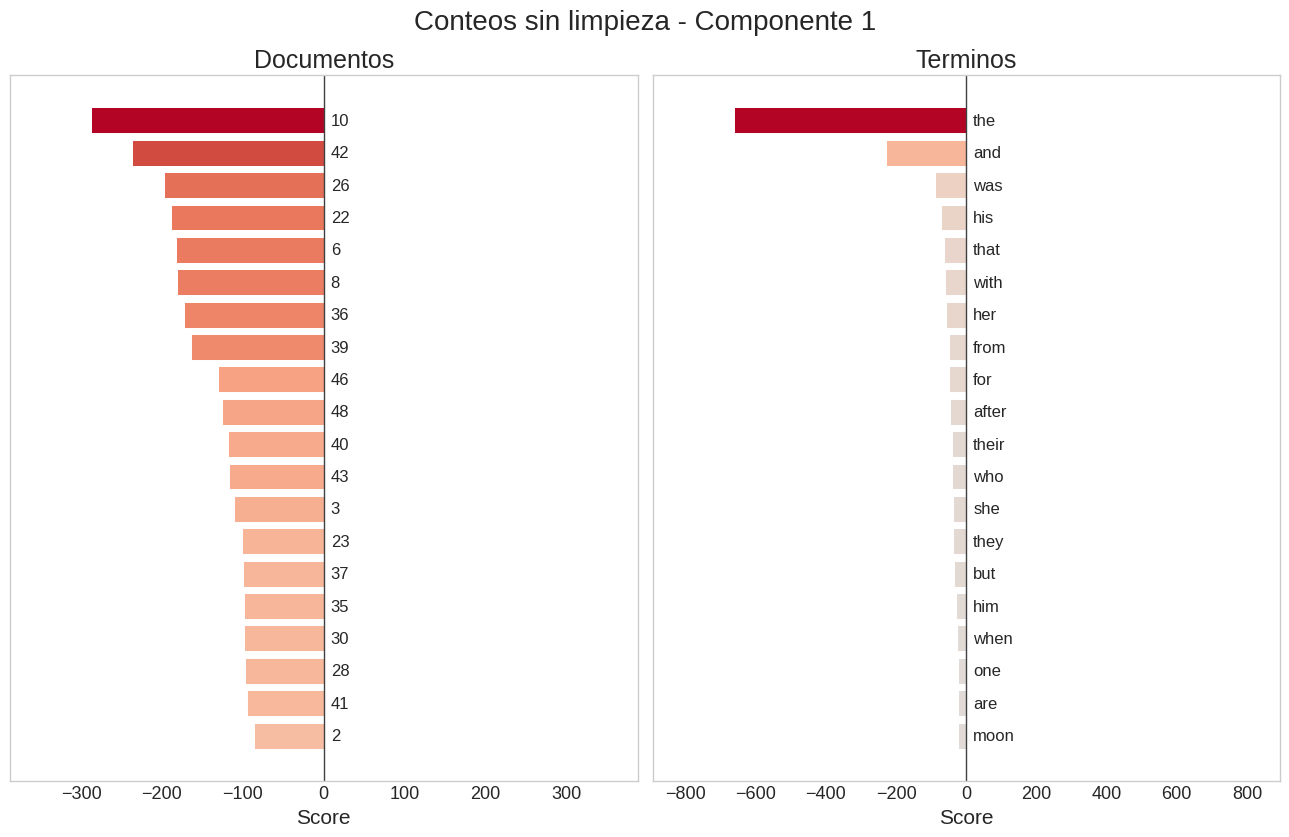

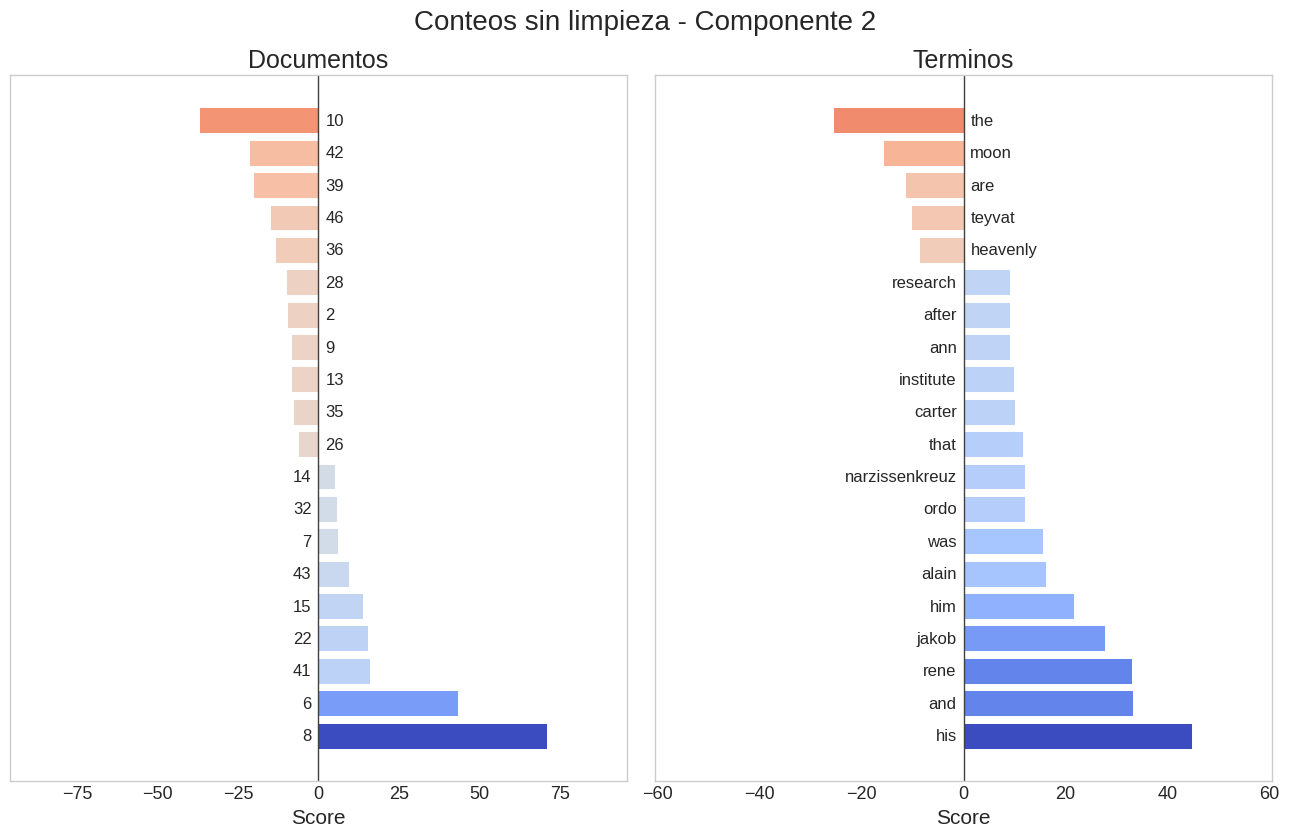

In [14]:
graficar_componentes(
    U_raw,
    s_raw,
    VT_raw,
    vocabulario_raw,
    etiquetas,
    componentes=2,
    k=20,
    titulo="Conteos sin limpieza",
)


### Los componentes estan capturando densidad?

,componente,tipo,variable,correlacion_pearson,p_pearson,correlacion_spearman,p_spearman
0,1,documentos,densidad_doc,0.948,1.966767e-24,0.962,1.632924e-27
1,1,terminos,densidad_termino,0.396,1.308460e-215,0.808,0.000000e+00
2,2,documentos,densidad_doc,0.648,6.245622e-07,0.609,4.322903e-06
3,2,terminos,densidad_termino,0.441,9.362372e-273,0.473,0.000000e+00


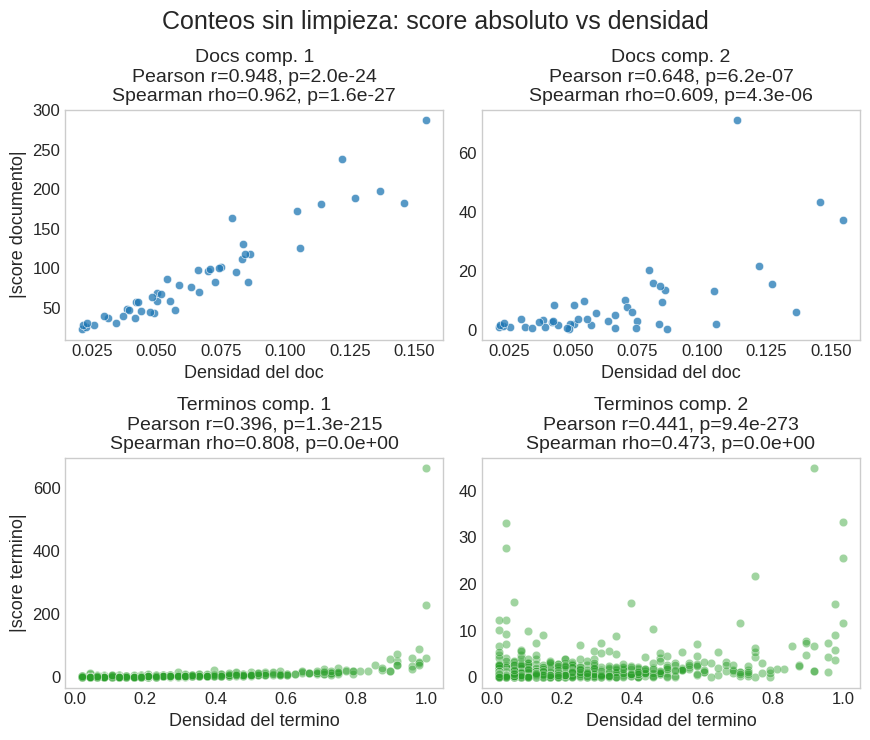

In [15]:
def correlaciones_actividad_componentes(U, s, VT, X_conteos, vocabulario, nombre, componentes=4):
    from scipy.stats import pearsonr, spearmanr

    densidad_doc = np.asarray((X_conteos > 0).sum(axis=1)).ravel() / X_conteos.shape[1]
    densidad_termino = np.asarray((X_conteos > 0).sum(axis=0)).ravel() / X_conteos.shape[0]

    def calcular_correlaciones(scores_abs, actividad):
        pearson, p_pearson = pearsonr(actividad, scores_abs)
        spearman, p_spearman = spearmanr(actividad, scores_abs)
        return pearson, p_pearson, spearman, p_spearman

    def formato_pvalor(p):
        return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"

    def titulo_correlacion(nombre_panel, componente, pearson, p_pearson, spearman, p_spearman):
        return (
            f"{nombre_panel} comp. {componente}\n"
            f"Pearson r={pearson:.3f}, p={formato_pvalor(p_pearson)}\n"
            f"Spearman rho={spearman:.3f}, p={formato_pvalor(p_spearman)}"
        )

    filas = []
    for componente in range(1, componentes + 1):
        idx = componente - 1
        score_docs = np.abs(s[idx] * VT[idx, :])
        score_terms = np.abs(s[idx] * U[:, idx])
        pares = [
            ("documentos", "densidad_doc", score_docs, densidad_doc),
            ("terminos", "densidad_termino", score_terms, densidad_termino),
        ]
        for tipo, variable, scores_abs, actividad in pares:
            pearson, p_pearson, spearman, p_spearman = calcular_correlaciones(scores_abs, actividad)
            filas.append(
                [
                    componente,
                    tipo,
                    variable,
                    round(float(pearson), 3),
                    float(p_pearson),
                    round(float(spearman), 3),
                    float(p_spearman),
                ]
            )

    tabla = pd.DataFrame(
        filas,
        columns=["componente", "tipo", "variable", "correlacion_pearson", "p_pearson", "correlacion_spearman", "p_spearman"],
    )
    display(tabla)

    fig, axes = plt.subplots(2, componentes, figsize=(4.4 * componentes, 7.5), sharex=False, sharey=False)
    if componentes == 1:
        axes = np.array(axes).reshape(2, 1)

    for componente in range(1, componentes + 1):
        idx = componente - 1
        score_docs = np.abs(s[idx] * VT[idx, :])
        score_terms = np.abs(s[idx] * U[:, idx])
        pearson_doc, p_pearson_doc, spearman_doc, p_spearman_doc = calcular_correlaciones(score_docs, densidad_doc)
        pearson_term, p_pearson_term, spearman_term, p_spearman_term = calcular_correlaciones(score_terms, densidad_termino)

        axes[0, idx].scatter(densidad_doc, score_docs, color="tab:blue", alpha=0.75, edgecolor="white", linewidth=0.5)
        axes[0, idx].set_title(titulo_correlacion("Docs", componente, pearson_doc, p_pearson_doc, spearman_doc, p_spearman_doc), fontsize=14)
        axes[0, idx].set_xlabel("Densidad del doc", fontsize=13)
        axes[0, idx].grid(False)
        axes[0, idx].tick_params(axis="both", labelsize=12)
        if idx == 0:
            axes[0, idx].set_ylabel("|score documento|", fontsize=13)

        axes[1, idx].scatter(densidad_termino, score_terms, color="tab:green", alpha=0.45, edgecolor="white", linewidth=0.4)
        axes[1, idx].set_title(titulo_correlacion("Terminos", componente, pearson_term, p_pearson_term, spearman_term, p_spearman_term), fontsize=14)
        axes[1, idx].set_xlabel("Densidad del termino", fontsize=13)
        axes[1, idx].grid(False)
        axes[1, idx].tick_params(axis="both", labelsize=12)
        if idx == 0:
            axes[1, idx].set_ylabel("|score termino|", fontsize=13)

    fig.suptitle(nombre, fontsize=18)
    plt.tight_layout()
    plt.show()

    return tabla


tabla_correlaciones_actividad_raw = correlaciones_actividad_componentes(
    U_raw,
    s_raw,
    VT_raw,
    X_raw,
    vocabulario_raw,
    "Conteos sin limpieza: score absoluto vs densidad",
    componentes=2,
)


## Limpieza

In [17]:
import spacy

try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except OSError as exc:
    raise OSError(
        "No encontre el modelo es_core_news_sm. Ejecuta la celda de instalacion: "
        "!python -m spacy download es_core_news_sm"
    ) from exc

stop_words = [
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"
]

stop_words_raw = sorted(set(stop_words))


def lematizar_lista(palabras):
    lemas = set()
    for palabra in palabras:
        doc = nlp(palabra)
        for token in doc:
            lema = token.lemma_.lower().strip()
            if lema:
                lemas.add(lema)
    return lemas


# Filtramos dos veces: primero en la forma original del token y luego en su lema.
# Esto evita que ruido de LaTeX como mathbb, times, hat o ldots sobreviva por cambios del lematizador.
stop_words_lem = lematizar_lista(stop_words_raw)
stop_words_total = sorted(set(stop_words_raw) | stop_words_lem)


def lematizar_texto(texto):
    doc = nlp(texto)
    lemas = []
    for token in doc:
        texto_token = token.text.lower().strip()
        lema = token.lemma_.lower().strip()
        if not texto_token or not lema or token.is_space:
            continue
        if len(texto_token) < 3 or len(lema) < 3:
            continue
        if texto_token in stop_words_total or lema in stop_words_total:
            continue
        lemas.append(lema)
    return " ".join(lemas)


documentos_lem = [lematizar_texto(texto) for texto in documentos]



print("Ejemplo original:")
print(documentos[0][:300])
print("\nEjemplo lematizado y filtrado:")
print(documentos_lem[0][:300])
print("\nStopwords finales:", stop_words_total[:40])
print("Stopwords de LaTeX presentes:", [p for p in ["mathbb", "times", "hat", "ldots"] if p in stop_words_total])


Ejemplo original:
the traveler currently traveling through teyvat to find the truth of the world and to reunite with their twin described as the child of dandelions by the aranara liloupar knows that they re an exiled prince princess ei found out that they re a star after being told the two watchers of temple of spac

Ejemplo lematizado y filtrado:
traveler currently traveling teyvat find truth world reunitir twin described child dandelions aranar liloupar know exiled prince princess found star told two watchers templar spacir seem know traveler melanta says traveler child humanity nihilitir say returnee ser stars last descendant subjugated ci

Stopwords finales: ['a', 'about', 'above', 'abovir', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'arir', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'betwear', 'between', 'bir', 'both', 'but', 'by', 'can', 'car', 'did', 'do', 'does', 'doing', 'don', 'down', 'during', 'each', 'few', 'for']
Stopwords d

### Matriz TF-IDF sobre documentos Lematizados con unigramas y bigramas

In [18]:
vectorizer_final = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    stop_words=stop_words_total,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
)

X_final = vectorizer_final.fit_transform(documentos_lem)
vocabulario_final = vectorizer_final.get_feature_names_out()
A_final = X_final.toarray().T

vectorizer_final_counts = CountVectorizer(vocabulary=vocabulario_final)
X_final_counts = vectorizer_final_counts.transform(documentos_lem)
frecuencias_final = np.asarray(X_final_counts.sum(axis=0)).ravel()

print("Forma de X_final (documentos x terminos):", X_final.shape)
print("Forma de A_final (terminos x documentos):", A_final.shape)
print("Primeros terminos del vocabulario final:", vocabulario_final[:30])
print("Unigramas:", sum(len(t.split()) == 1 for t in vocabulario_final))
print("Bigramas:", sum(len(t.split()) == 2 for t in vocabulario_final))


/home/uc/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['tho'] not in stop_words.
  warnings.warn(


Forma de X_final (documentos x terminos): (48, 3673)
Forma de A_final (terminos x documentos): (3673, 48)
Primeros terminos del vocabulario final: ['aaru' 'aaru village' 'abandon' 'abandoned' 'abilities' 'ability' 'able'
 'able see' 'abodir' 'abolished' 'absorbed' 'absorbing' 'abundance'
 'abyss' 'abyss age' 'abyss appeared' 'abyss completely' 'abyss order'
 'abyss power' 'abyss using' 'abyssal' 'abyssal contamination'
 'abyssal corruption' 'abyssal energy' 'abyssal influence'
 'abyssal monsters' 'abyssal power' 'accepted' 'access' 'accidentally']
Unigramas: 2662
Bigramas: 1011


### Que palabras dominan despues de limpiar

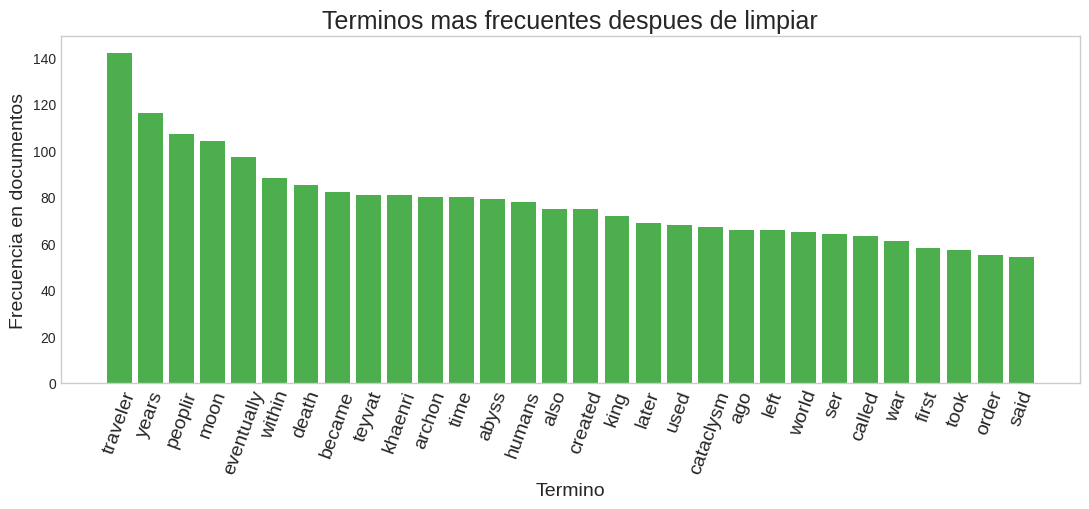

Top 30 terminos mas frecuentes despues de limpiar:


array(['traveler', 'years', 'peoplir', 'moon', 'eventually', 'within',
       'death', 'became', 'teyvat', 'khaenri', 'archon', 'time', 'abyss',
       'humans', 'also', 'created', 'king', 'later', 'used', 'cataclysm',
       'ago', 'left', 'world', 'ser', 'called', 'war', 'first', 'took',
       'order', 'said'], dtype=object)

In [19]:
indices_frecuentes_final = np.argsort(frecuencias_final)[::-1][:30]
terminos_frecuentes_final = vocabulario_final[indices_frecuentes_final]
conteos_frecuentes_final = frecuencias_final[indices_frecuentes_final]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.bar(terminos_frecuentes_final, conteos_frecuentes_final, color="tab:green", alpha=0.85)
ax.set_title("Terminos mas frecuentes despues de limpiar", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia en documentos", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.show()

# Print top 30 terms and their counts
print("Top 30 terminos mas frecuentes despues de limpiar:")
terminos_frecuentes_final
